# ทดสอบโมเดลที่บันทึกไว้ 3 ตัวกับข้อมูลภายนอก

Notebook นี้แยกจาก Notebook หลัก (`MaliciousURL_Full_CL.ipynb`) **ไม่ได้เทรนอะไรใหม่** แค่โหลดไฟล์โมเดลที่บันทึกไว้แล้วมาทดสอบกับข้อมูลภายนอกชุดเดียวกัน
เพื่อเทียบว่าโมเดลไหนใช้งานกับข้อมูลจริงนอก Kaggle ได้ดีที่สุด

| # | ไฟล์ | โมเดล | label ที่ใช้เทรน | ทายอย่างไร |
|---|---|---|---|---|
| 1 | `MaliciousURL_Full_CL/url_model_original.joblib` | Stacking (LinearSVC + ComplementNB + lexical → HistGB) | label เดิมของ Kaggle | threshold 0.6 |
| 2 | `MaliciousURL_Full_CL/url_model.joblib` | Stacking แบบเดียวกัน | Train แบบ **Relabel** (Confident Learning) | threshold 0.6 |
| 3 | `MiniProject_FixedLabels/models/final_model.joblib` | Logistic Regression (char 2–5 TF-IDF + lexical 27 ตัว) | label ที่ **แก้การสลับของ PhishStorm** แล้ว | argmax (ไม่มี threshold) — ใช้ใน Web App |

นอกจากนี้ทดสอบ **Stacking ทั้งสองไฟล์แบบไม่ใช้ threshold (argmax)** ด้วย คือเลือกคลาสที่ความน่าจะเป็นสูงสุดตรง ๆ
เพื่อแยกให้เห็นว่าผลที่ต่างกันมาจาก **label ที่ใช้เทรน** หรือมาจาก **threshold** รวมทั้งหมด 5 แบบ

**ข้อมูลภายนอก** (ชุดเดียวกับข้อ 7 และ 9.2 ของ Notebook หลัก ไม่เคยใช้เทรน)

| ชุด | คลาส | จำนวน | วัดอะไร |
|---|---|---:|---|
| PhishTank `online-valid` (30 ก.ย. 2569) | phishing | 77,755 | จับ phishing ได้กี่ % |
| URLhaus `csv_recent` (30 วันล่าสุด) | malware | 15,326 | จับ malware ได้กี่ % |
| DeepURLBench (สุ่มเท่ากันทุกคลาส) | benign / phishing / malware | 164,782 | เตือนผิดกับเว็บปกติ, Macro-F1 แบบ 3 คลาส |

> URL ที่แสดงในตารางถูก defang (`http` → `hxxp`, `.` → `[.]`) เพื่อไม่ให้กดเปิดได้

In [1]:
import sys, time, warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix

warnings.filterwarnings("ignore")
BASE = Path("..").resolve()
FULL, MINI = BASE / "MaliciousURL_Full_CL", BASE / "MiniProject_FixedLabels"
sys.path[:0] = [str(FULL), str(MINI)]          # urlfeat.py (Stacking) และ url_utils.py (LogReg) ต้อง import ได้ตอนโหลดโมเดล
import urlfeat, url_utils

LABELS = ["benign", "defacement", "malware", "phishing"]
THREAT = ["defacement", "malware", "phishing"]
pd.set_option("display.max_colwidth", 90)
plt.rcParams["font.family"] = "Leelawadee UI"        # ฟอนต์ที่แสดงภาษาไทยได้บน Windows

def defang(s):
    return pd.Series(s, dtype="string").str.replace("http", "hxxp", regex=False).str.replace(".", "[.]", regex=False)

for p in [FULL / "url_model_original.joblib", FULL / "url_model.joblib", MINI / "models" / "final_model.joblib"]:
    print(f"{p.relative_to(BASE)}  {p.stat().st_size / 1e6:6.1f} MB")

MaliciousURL_Full_CL\url_model_original.joblib   119.4 MB
MaliciousURL_Full_CL\url_model.joblib   115.7 MB
MiniProject_FixedLabels\models\final_model.joblib     4.7 MB


### ผลลัพธ์ที่ได้จากการรัน
- พบไฟล์ครบ 3 ไฟล์: Stacking label เดิม **119.4 MB**, Stacking Relabel **115.7 MB**, LogReg **4.7 MB**
- Stacking ใหญ่เพราะใช้ hashing 1.5 ล้านมิติ ส่วน LogReg ใช้ TF-IDF 200,000 มิติ จึงเล็กกว่า 25 เท่า

## 1. โหลดโมเดลทั้ง 3 ตัว

- Stacking เก็บเป็น **bundle** (dict) ที่มีตัวแปลงข้อความ, LinearSVC, ComplementNB, HistGB และ threshold ใช้ทายด้วย `urlfeat.predict_urls` ตัวเดียวกับ Notebook หลัก
- Logistic Regression เก็บเป็น `Pipeline` ของ scikit-learn ที่ normalize URL เองภายใน ใช้ `predict` ได้ตรง ๆ

In [2]:
t = time.time()
models = {
    "Stacking: label เดิม": joblib.load(FULL / "url_model_original.joblib"),
    "Stacking: Relabel": joblib.load(FULL / "url_model.joblib"),
    "LogReg: แก้การสลับ (Web App)": joblib.load(MINI / "models" / "final_model.joblib"),
}
# Stacking แบบไม่ใช้ threshold: ใช้ไฟล์เดียวกัน แค่ตั้ง threshold = None ให้ฟังก์ชัน predict ใช้ argmax แทน
models = {
    "Stacking: label เดิม": models["Stacking: label เดิม"],
    "Stacking: label เดิม (argmax)": {**models["Stacking: label เดิม"], "threshold": None},
    "Stacking: Relabel": models["Stacking: Relabel"],
    "Stacking: Relabel (argmax)": {**models["Stacking: Relabel"], "threshold": None},
    "LogReg: แก้การสลับ (Web App)": models["LogReg: แก้การสลับ (Web App)"],
}
print(f"โหลดเสร็จใน {time.time() - t:.0f} วินาที")
for name, m in models.items():
    if isinstance(m, dict):
        print(f"{name:32s} bundle | threshold = {m['threshold'] if m['threshold'] is not None else 'ไม่ใช้ (argmax)'} | meta = {type(m['meta']).__name__}")
    else:
        print(f"{name:32s} {type(m).__name__} | steps = {list(m.named_steps)} | classes = {list(m.classes_)}")

def predict(model, urls):
    """คืนคลาสที่ทาย (numpy array ของข้อความ) ไม่ว่าจะเป็น bundle หรือ Pipeline"""
    if isinstance(model, dict) and model["threshold"] is None:      # Stacking แบบ argmax
        norm = urlfeat.normalize(list(urls)).to_numpy(dtype=object)
        X = urlfeat.text_matrix(model, norm)
        Z = np.hstack([model["svc"].decision_function(X), model["nb"].predict_log_proba(X), urlfeat.lexical_features(norm)])
        return np.array(urlfeat.LABELS)[model["meta"].predict_proba(Z).argmax(1)]
    if isinstance(model, dict):                                        # Stacking + threshold 0.6
        return urlfeat.predict_urls(model, list(urls))["prediction"].to_numpy()
    return model.predict(np.asarray(urls, dtype=object))

check = ["google.com", "https://www.google.com/", "http://185.12.33.4:8080/bins/x86",
         "paypal-account-verify.secure-login.xyz/update/index.php"]
pd.DataFrame({name: predict(m, check) for name, m in models.items()}, index=defang(check))

โหลดเสร็จใน 3 วินาที
Stacking: label เดิม             bundle | threshold = 0.6 | meta = HistGradientBoostingClassifier
Stacking: label เดิม (argmax)    bundle | threshold = ไม่ใช้ (argmax) | meta = HistGradientBoostingClassifier
Stacking: Relabel                bundle | threshold = 0.6 | meta = HistGradientBoostingClassifier
Stacking: Relabel (argmax)       bundle | threshold = ไม่ใช้ (argmax) | meta = HistGradientBoostingClassifier
LogReg: แก้การสลับ (Web App)     Pipeline | steps = ['normalize', 'features', 'classifier'] | classes = ['benign', 'defacement', 'malware', 'phishing']


,Stacking: label เดิม,Stacking: label เดิม (argmax),Stacking: Relabel,Stacking: Relabel (argmax),LogReg: แก้การสลับ (Web App)
google[.]com,benign,benign,benign,benign,phishing
hxxps://www[.]google[.]com/,benign,benign,benign,benign,phishing
hxxp://185[.]12[.]33[.]4:8080/bins/x86,malware,malware,malware,malware,malware
paypal-account-verify[.]secure-login[.]xyz/update/index[.]php,phishing,phishing,phishing,phishing,phishing


### ผลลัพธ์ที่ได้จากการรัน
- โหลดทั้ง 3 ไฟล์ใน 3 วินาที แล้วสร้าง Stacking แบบ argmax จากไฟล์เดียวกัน (ไม่ต้องเทรนใหม่) รวมเป็น **5 แบบ**
- ทดสอบ 4 URL: ทุกแบบทาย `185.12.33.4:8080/bins/x86` = malware และ URL ปลอม PayPal = phishing ถูกต้อง
- **ต่างกันที่ `google.com`:** Stacking ทั้ง 4 แบบทาย benign แต่ **LogReg ทาย phishing**
  เพราะ Kaggle มี URL ของ google.com ติด phishing 616 แถว และ malware 205 แถว (ข้อ 8.1 ของ Notebook หลัก) LogReg ที่เป็นเส้นตรงจึงให้น้ำหนัก `google` ไปทาง phishing
  ส่วน Stacking มี HistGB ชั้นบนที่ใช้ lexical ช่วยแยกว่า URL สั้น ๆ แบบนี้น่าจะปกติ

## 2. โหลดข้อมูลภายนอก และแยก "โดเมนที่ไม่เคยเห็นใน Kaggle"

Kaggle มี URL บางส่วนจาก PhishTank รุ่นเก่า จึงรายงาน 2 มุมเหมือน Notebook หลัก:
**ทั้งหมด** และ **เฉพาะ registrable domain ที่ไม่มีใน Kaggle เลย** (เช่น `docs.google.com` → `google.com`)
ใช้ `tldextract` แบบ offline (รายชื่อ public suffix ที่มากับไลบรารี)

In [3]:
import tldextract
_ext = tldextract.TLDExtract(suffix_list_urls=())
_cache = {}
def registrable(h):
    if h not in _cache:
        _cache[h] = (_ext(h).top_domain_under_public_suffix or h) if h else ""
    return _cache[h]

def hosts(urls):
    return urlfeat.split_parts(urlfeat.normalize(urls))[0].str.replace(r":\d+$", "", regex=True)

kaggle = pd.read_csv(MINI / "data" / "malicious_phish.csv")
kaggle_domains = set(hosts(kaggle["url"]).map(registrable))

EXT = FULL / "data" / "external"
ext = {
    "PhishTank": pd.read_csv(EXT / "phishtank_online_valid.csv"),
    "URLhaus": pd.read_csv(EXT / "urlhaus_recent.csv"),
    "DeepURLBench": pd.read_csv(EXT / "deepurlbench_sample.csv"),
}
for name, d in ext.items():
    d["unseen"] = ~hosts(d["url"]).map(registrable).isin(kaggle_domains).to_numpy()
pd.DataFrame({name: {"rows": len(d), "unseen domain": int(d["unseen"].sum()), "% unseen": round(d["unseen"].mean() * 100, 1),
                     "classes": ", ".join(sorted(d["type"].unique()))} for name, d in ext.items()}).T

,rows,unseen domain,% unseen,classes
PhishTank,77755,51524,66.3,phishing
URLhaus,15326,15026,98.0,malware
DeepURLBench,164782,141678,86.0,"benign, malware, phishing"


### ผลลัพธ์ที่ได้จากการรัน
| ชุด | จำนวน | โดเมนไม่เคยเห็นใน Kaggle |
|---|---:|---:|
| PhishTank | 77,755 | 51,524 (66.3%) |
| URLhaus | 15,326 | 15,026 (98.0%) |
| DeepURLBench | 164,782 | 141,678 (86.0%) |

จำนวน "ไม่เคยเห็น" ต่างจาก Notebook หลักเล็กน้อย (51,524 กับ 51,525 และ 141,678 กับ 141,690) เพราะที่นี่ใช้โดเมนจากไฟล์ Kaggle ทั้งไฟล์ ส่วน Notebook หลักใช้หลังทำความสะอาด

## 3. ทำนายข้อมูลภายนอกด้วยทั้ง 3 โมเดล

ทำนาย 257,863 URL ต่อแบบ (5 แบบ) แล้วเก็บผลไว้ใช้ทุกตารางข้างล่าง

In [4]:
pred = {}
for mname, m in models.items():
    t = time.time()
    for dname, d in ext.items():
        pred[(mname, dname)] = predict(m, d["url"])
    print(f"{mname:32s} {time.time() - t:5.0f} วินาที")

Stacking: label เดิม                42 วินาที


Stacking: label เดิม (argmax)       42 วินาที


Stacking: Relabel                   39 วินาที


Stacking: Relabel (argmax)          38 วินาที


LogReg: แก้การสลับ (Web App)        32 วินาที


### ผลลัพธ์ที่ได้จากการรัน
ใช้เวลาทำนาย 257,863 URL: Stacking ประมาณ 38–42 วินาทีต่อแบบ, LogReg 32 วินาที (เร็วพอสำหรับ Web App ทุกแบบ)

## 4. ตารางสรุปผล

| ตัวชี้วัด | ความหมาย |
|---|---|
| Recall phishing / malware | ของอันตรายประเภทนั้นถูกทาย **ถูกชนิด** กี่ % |
| ทายว่าอันตราย (แบบใดก็ได้) | ของอันตรายถูกทายเป็นคลาสอันตรายใดก็ได้ (ไม่ปล่อยเป็น benign) กี่ % |
| False alarm | เว็บปกติถูกทายว่าอันตรายกี่ % (ยิ่งน้อยยิ่งดี) |
| Macro-F1 (3 คลาส) | เฉลี่ย F1 ของ benign, malware, phishing บน DeepURLBench |

In [5]:
rows = []
for mname in models:
    for dname, d in ext.items():
        for scope, mask in [("ทั้งหมด", np.ones(len(d), bool)), ("โดเมนไม่เคยเห็น", d["unseen"].to_numpy())]:
            yt, yp = d["type"].to_numpy()[mask], pred[(mname, dname)][mask]
            r = {"model": mname, "dataset": dname, "scope": scope, "rows": int(mask.sum())}
            for c in ["phishing", "malware", "benign"]:
                if c in set(yt):
                    r[f"recall_{c}"] = (yp[yt == c] == c).mean()
            r["ทายว่าอันตราย"] = (yp[yt != "benign"] != "benign").mean()
            if "benign" in set(yt):
                r["false_alarm"] = (yp[yt == "benign"] != "benign").mean()
                r["macro_f1_3class"] = f1_score(yt, yp, labels=["benign", "malware", "phishing"], average="macro")
            rows.append(r)
res = pd.DataFrame(rows)

headline = pd.DataFrame({
    mname: {
        "PhishTank: จับ phishing": res.query("model == @mname and dataset == 'PhishTank' and scope == 'ทั้งหมด'")["recall_phishing"].item(),
        "URLhaus: จับ malware": res.query("model == @mname and dataset == 'URLhaus' and scope == 'ทั้งหมด'")["recall_malware"].item(),
        "DeepURLBench: เตือนผิด (เว็บปกติ)": res.query("model == @mname and dataset == 'DeepURLBench' and scope == 'ทั้งหมด'")["false_alarm"].item(),
        "DeepURLBench: Macro-F1 (3 คลาส)": res.query("model == @mname and dataset == 'DeepURLBench' and scope == 'ทั้งหมด'")["macro_f1_3class"].item(),
        "DeepURLBench: จับ phishing": res.query("model == @mname and dataset == 'DeepURLBench' and scope == 'ทั้งหมด'")["recall_phishing"].item(),
        "DeepURLBench: จับ malware": res.query("model == @mname and dataset == 'DeepURLBench' and scope == 'ทั้งหมด'")["recall_malware"].item(),
    } for mname in models})
headline.style.format("{:.3f}")

,Stacking: label เดิม,Stacking: label เดิม (argmax),Stacking: Relabel,Stacking: Relabel (argmax),LogReg: แก้การสลับ (Web App)
PhishTank: จับ phishing,0.936,0.914,0.927,0.902,0.833
URLhaus: จับ malware,0.946,0.945,0.944,0.943,0.941
DeepURLBench: เตือนผิด (เว็บปกติ),0.756,0.689,0.726,0.672,0.498
DeepURLBench: Macro-F1 (3 คลาส),0.333,0.352,0.338,0.353,0.425
DeepURLBench: จับ phishing,0.722,0.697,0.722,0.702,0.778
DeepURLBench: จับ malware,0.122,0.120,0.108,0.107,0.111


### ผลลัพธ์ที่ได้จากการรัน
| ตัวชี้วัด | Stacking เดิม + th 0.6 | Stacking เดิม argmax | Relabel + th 0.6 | Relabel argmax | LogReg แก้การสลับ (argmax) |
|---|---:|---:|---:|---:|---:|
| PhishTank: จับ phishing | **93.6%** | 91.4% | 92.7% | 90.2% | 83.3% |
| URLhaus: จับ malware | **94.6%** | 94.5% | 94.4% | 94.3% | 94.1% |
| DeepURLBench: เตือนผิดกับเว็บปกติ (ต่ำ = ดี) | 75.6% | 68.9% | 72.6% | 67.2% | **49.8%** |
| DeepURLBench: Macro-F1 (3 คลาส) | 0.333 | 0.352 | 0.338 | 0.353 | **0.425** |
| DeepURLBench: จับ phishing | 72.2% | 69.7% | 72.2% | 70.2% | **77.8%** |
| DeepURLBench: จับ malware | **12.2%** | 12.0% | 10.8% | 10.7% | 11.1% |

- **ตัวเลขของ Stacking + threshold ตรงกับ Notebook หลัก (ข้อ 7 และ 9.2)** ยืนยันว่าไฟล์ที่บันทึกไว้ให้ผลเหมือนตอนเทรน (ค่าดิบเท่ากันถึงทศนิยม 4 ตำแหน่ง เช่น URLhaus 0.9465 และเตือนผิด 0.7565 ซึ่งข้อ 7 ปัดเป็น 94.7% และ 75.7%)
- **ผลของ threshold:** เอา threshold ออก (argmax) เตือนผิดลดประมาณ 5–7 จุด (75.6% → 68.9%) แต่จับ phishing ของ PhishTank ลดประมาณ 2.5 จุด เป็นการแลกเปลี่ยนตามที่ตั้งใจไว้ในข้อ 5.5
- **ผลของ label:** แม้เทียบแบบ argmax เหมือนกัน Stacking ยังเตือนผิด 67–69% ส่วน LogReg ที่แก้การสลับเหลือ **49.8%** แปลว่า **ความต่างส่วนใหญ่มาจาก label ที่ใช้เทรน ไม่ใช่จาก threshold**
- **Relabel** ต่างจากตัวเดิมน้อยมาก (เตือนผิดลด 2–3 จุด) เพราะ Confident Learning แก้ label ผิดของ PhishStorm ได้แค่ 5%
- **LogReg ที่แก้การสลับ** เตือนผิดน้อยที่สุดและ Macro-F1 บน DeepURLBench สูงสุด (0.425) แลกกับจับ phishing ของ PhishTank ได้น้อยกว่า (83.3%)

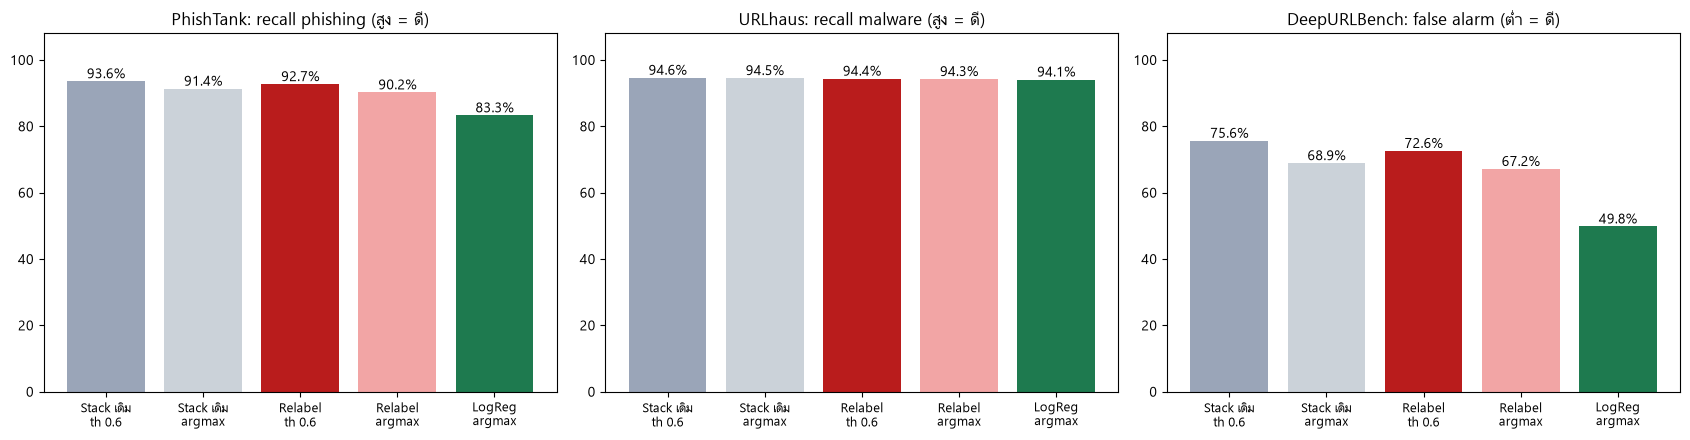

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
colors = ["#9AA5B8", "#CBD2D9", "#B91C1C", "#F2A5A5", "#1E7A4F"]
for ax, (row, title, better) in zip(axes, [("PhishTank: จับ phishing", "PhishTank: recall phishing", "สูง = ดี"),
                                           ("URLhaus: จับ malware", "URLhaus: recall malware", "สูง = ดี"),
                                           ("DeepURLBench: เตือนผิด (เว็บปกติ)", "DeepURLBench: false alarm", "ต่ำ = ดี")]):
    v = headline.loc[row] * 100
    bars = ax.bar(["Stack เดิม\nth 0.6", "Stack เดิม\nargmax", "Relabel\nth 0.6", "Relabel\nargmax", "LogReg\nargmax"], v.values, color=colors)
    ax.bar_label(bars, fmt="%.1f%%")
    ax.set_title(f"{title} ({better})")
    ax.set_ylim(0, 108); ax.tick_params(axis="x", labelsize=9)
plt.tight_layout(); plt.show()

### ผลลัพธ์ที่ได้จากการรัน
กราฟแท่งสรุป 3 ตัวชี้วัดหลักของทั้ง 5 แบบ: สองกราฟแรก (สูง = ดี) Stacking + threshold ชนะเล็กน้อย กราฟที่สาม (ต่ำ = ดี) LogReg ที่แก้การสลับชนะห่างที่สุด แม้เทียบกับ Stacking แบบ argmax

## 5. ผลเต็มทุกชุด ทั้งหมด และเฉพาะโดเมนที่ไม่เคยเห็น

In [7]:
cols = ["model", "dataset", "scope", "rows", "recall_phishing", "recall_malware", "recall_benign", "ทายว่าอันตราย", "false_alarm", "macro_f1_3class"]
res[cols].set_index(["dataset", "scope", "model"]).sort_index(level=[0, 1], sort_remaining=False).style.format(
    {c: "{:.3f}" for c in cols[4:]}, na_rep="–").format({"rows": "{:,}"})

### ผลลัพธ์ที่ได้จากการรัน
**เฉพาะโดเมนที่ไม่เคยเห็นใน Kaggle** ให้ทิศทางเดียวกับทั้งหมด

| ชุด (โดเมนไม่เคยเห็น) | เดิม + th 0.6 | เดิม argmax | Relabel + th 0.6 | Relabel argmax | LogReg |
|---|---:|---:|---:|---:|---:|
| PhishTank: จับ phishing | 93.0% | 90.7% | 92.7% | 90.7% | 81.1% |
| URLhaus: จับ malware | 94.7% | 94.6% | 94.5% | 94.4% | 94.5% |
| DeepURLBench: เตือนผิด | 80.5% | 73.3% | 77.2% | 71.5% | **51.9%** |
| DeepURLBench: Macro-F1 | 0.308 | 0.331 | 0.315 | 0.333 | **0.420** |

- ตัวเลขแทบไม่ลดเมื่อดูเฉพาะโดเมนใหม่ แปลว่าทุกแบบไม่ได้แค่จำชื่อเว็บจาก Kaggle
- "ทายว่าอันตราย (แบบใดก็ได้)" ของ Stacking + threshold สูงที่สุดทุกชุด (เช่น PhishTank 94.8% เทียบกับ argmax 92.4% และ LogReg 85.8%) เพราะ threshold 0.6 ทำให้ทาย benign ยากขึ้น

## 6. DeepURLBench: แต่ละโมเดลทายเว็บแต่ละประเภทเป็นอะไร (% ของแต่ละแถว)

แถว = คลาสจริง, คอลัมน์ = คลาสที่ทาย ตัวเลขในแนวทแยงคือ recall

In [8]:
dub = ext["DeepURLBench"]
for mname in models:
    cm = pd.crosstab(dub["type"], pred[(mname, "DeepURLBench")], normalize="index").reindex(columns=LABELS, fill_value=0) * 100
    print(mname); display(cm.round(1))

Stacking: label เดิม


col_0,benign,defacement,malware,phishing
type,,,,
benign,24.4,13.5,4.2,57.9
malware,9.2,3.4,12.2,75.3
phishing,4.6,0.9,22.2,72.2


Stacking: label เดิม (argmax)


col_0,benign,defacement,malware,phishing
type,,,,
benign,31.1,12.4,4.0,52.5
malware,13.2,2.9,12.0,71.9
phishing,7.4,0.8,22.1,69.7


Stacking: Relabel


col_0,benign,defacement,malware,phishing
type,,,,
benign,27.4,12.3,3.6,56.7
malware,10.4,3.3,10.8,75.4
phishing,5.3,0.9,21.5,72.2


Stacking: Relabel (argmax)


col_0,benign,defacement,malware,phishing
type,,,,
benign,32.8,11.4,3.5,52.3
malware,14.0,2.9,10.7,72.5
phishing,7.5,0.8,21.5,70.2


LogReg: แก้การสลับ (Web App)


col_0,benign,defacement,malware,phishing
type,,,,
benign,50.2,6.1,5.4,38.3
malware,25.6,0.8,11.1,62.4
phishing,8.0,0.3,13.9,77.8


### ผลลัพธ์ที่ได้จากการรัน
| จริง \ ทาย | เดิม + th 0.6 | เดิม argmax | Relabel + th 0.6 | Relabel argmax | LogReg |
|---|---:|---:|---:|---:|---:|
| benign → benign (ถูก) | 24.4% | 31.1% | 27.4% | 32.8% | **50.2%** |
| benign → phishing (เตือนผิด) | 57.9% | 52.5% | 56.7% | 52.3% | **38.3%** |
| benign → defacement (เตือนผิด) | 13.5% | 12.4% | 12.3% | 11.4% | **6.1%** |
| malware → phishing | 75.3% | 71.9% | 75.4% | 72.5% | 62.4% |
| malware → benign (หลุด) | 9.2% | 13.2% | 10.4% | 14.0% | **25.6%** |

- เอา threshold ออกช่วยให้ทายเว็บปกติถูกเพิ่มแค่ 5–7 จุด (24.4% → 31.1%) แต่ LogReg ที่แก้การสลับทายถูก **50.2%**
- LogReg เตือนผิดเป็น defacement ลดลงครึ่งหนึ่ง แต่ malware ของ DeepURLBench หลุดเป็น benign มากขึ้น (25.6%) เพราะ malware ชุดนี้ใช้โดเมนธรรมดา ซึ่ง Kaggle ไม่ค่อยมี
- ทุกแบบยังทาย malware ส่วนใหญ่เป็น phishing (ยังนับว่าเตือน แต่ผิดชนิด)

## 7. URLhaus แยกตามชนิด host

URLhaus ส่วนใหญ่เป็น URL ที่ใช้ IP ตรง ๆ ซึ่งจับง่าย จึงแยกดูกลุ่มที่ใช้ชื่อโดเมนด้วย

In [9]:
uh = ext["URLhaus"]
is_ip = hosts(uh["url"]).str.fullmatch(r"\d{1,3}(?:\.\d{1,3}){3}").fillna(False).to_numpy()
pd.DataFrame({mname: {"host = IP (%.1f%%)" % (is_ip.mean() * 100): (pred[(mname, "URLhaus")][is_ip] == "malware").mean(),
                      "host = ชื่อโดเมน (%.1f%%)" % ((~is_ip).mean() * 100): (pred[(mname, "URLhaus")][~is_ip] == "malware").mean()}
              for mname in models}).style.format("{:.3f}")

,Stacking: label เดิม,Stacking: label เดิม (argmax),Stacking: Relabel,Stacking: Relabel (argmax),LogReg: แก้การสลับ (Web App)
host = IP (89.6%),0.985,0.985,0.987,0.987,1.000
host = ชื่อโดเมน (10.4%),0.617,0.607,0.575,0.564,0.436


### ผลลัพธ์ที่ได้จากการรัน
| host | เดิม + th 0.6 | เดิม argmax | Relabel + th 0.6 | Relabel argmax | LogReg |
|---|---:|---:|---:|---:|---:|
| IP address (89.6%) | 98.5% | 98.5% | 98.7% | 98.7% | **100.0%** |
| ชื่อโดเมน (10.4%) | **61.7%** | 60.7% | 57.5% | 56.4% | 43.6% |

malware ที่ใช้ IP จับได้เกือบครบทุกแบบ (threshold แทบไม่มีผล) แต่ malware ที่ใช้ชื่อโดเมนยังเป็นจุดอ่อน โดยเฉพาะ LogReg (43.6%)

## 8. ตัวอย่าง URL ที่โมเดลเห็นต่างกัน

สุ่มเว็บปกติจาก DeepURLBench ที่ LogReg ทายถูกแต่ Stacking (label เดิม) เตือนผิด และกลับกัน เพื่อดูว่าโมเดลต่างกันแบบไหน

In [10]:
yt = dub["type"].to_numpy()
p_orig, p_lr = pred[("Stacking: label เดิม", "DeepURLBench")], pred[("LogReg: แก้การสลับ (Web App)", "DeepURLBench")]
a = dub[(yt == "benign") & (p_lr == "benign") & (p_orig != "benign")]
b = dub[(yt == "benign") & (p_lr != "benign") & (p_orig == "benign")]
print(f"เว็บปกติที่ LogReg ถูก แต่ Stacking เดิมเตือนผิด: {len(a):,} | กลับกัน: {len(b):,}")
show = a.sample(8, random_state=42)
display(pd.DataFrame({"url": defang(show["url"]).values, "Stacking เดิม": p_orig[show.index], "LogReg": p_lr[show.index]}))

เว็บปกติที่ LogReg ถูก แต่ Stacking เดิมเตือนผิด: 17,103 | กลับกัน: 2,656


,url,Stacking เดิม,LogReg
0,hxxp://www[.]ocean-opto[.]com,phishing,benign
1,hxxps://andimax[.]com[.]ua/bernovich,defacement,benign
2,hxxps://www[.]hellsms[.]com/party-animal/the-rules,defacement,benign
3,hxxps://www[.]tenable[.]com,phishing,benign
4,hxxps://www[.]basicscience-rcst[.]com,phishing,benign
5,hxxps://www[.]taylorpassine[.]com,phishing,benign
6,hxxps://www[.]textileexchange[.]org/feature/recover-2021,phishing,benign
7,hxxp://epaper[.]mis[.]nsysu[.]edu[.]tw/papers/20021011/2002101110[.]htm,phishing,benign


### ผลลัพธ์ที่ได้จากการรัน
- เว็บปกติที่ **LogReg ถูก แต่ Stacking เดิมเตือนผิด: 17,103 URL** ส่วนกลับกันมีแค่ 2,656 URL
- ตัวอย่างเป็นเว็บบริษัทและมหาวิทยาลัยทั่วไป เช่น `tenable.com`, `textileexchange.org/feature/...`, `epaper.mis.nsysu.edu.tw/papers/...`
  ซึ่งตรงกับรูปแบบของเว็บปกติ PhishStorm ที่ถูกติด phishing ใน Kaggle (เว็บองค์กร + path) โมเดลที่เทรนจาก label เดิมจึงเรียนว่ารูปแบบนี้ = phishing

## 9. สรุป
| | Stacking เดิม + threshold 0.6 | Stacking argmax (เดิม / Relabel) | Stacking Relabel + threshold 0.6 | LogReg แก้การสลับ |
|---|---|---|---|---|
| จุดเด่น | จับของอันตรายได้มากสุด (PhishTank 93.6%, URLhaus 94.6%) | เตือนผิดลดลง 5–7 จุดจากแบบ threshold | ใกล้เคียงตัวเดิม เตือนผิดลดเล็กน้อย | **เตือนผิดน้อยสุด (49.8%)**, Macro-F1 ภายนอกสูงสุด, ไฟล์เล็ก 4.7 MB, อธิบายได้ |
| จุดอ่อน | เตือนผิดกับเว็บปกติ 75.6% | ยังเตือนผิด 67–69% และจับ phishing ลดลง | ยังเตือนผิด 72.6% | จับ phishing ของ PhishTank น้อยกว่า 8–10 จุด, malware แบบโดเมน 43.6%, ทาย google.com ผิด |

**ข้อสรุป**
1. **threshold มีผลน้อยกว่า label:** เอา threshold ออกลดเตือนผิดได้ 5–7 จุด แต่การแก้ label ที่ต้นเหตุ (สลับ PhishStorm กลับ) ลดได้อีกเกือบ 20 จุด (68.9% → 49.8%)
2. **การแก้ label ที่ต้นเหตุช่วยได้มากกว่า Confident Learning มาก** Relabel ลดเตือนผิดได้แค่ 2–3 จุด
3. ไม่มีแบบไหนชนะทุกด้าน: ถ้าเน้น **จับให้ได้มากที่สุด** ใช้ Stacking เดิม + threshold ถ้าเน้น **ใช้งานจริงกับเว็บทั่วไปโดยไม่เตือนผิดบ่อย** ใช้ LogReg ที่แก้การสลับ
4. **Web App เลือก LogReg ที่แก้การสลับ** เพราะผู้ใช้ส่วนใหญ่จะกรอกเว็บปกติ ถ้าเตือนผิด 3 ใน 4 ครั้งผู้ใช้จะไม่เชื่อระบบ อีกทั้งไฟล์เล็กและอธิบายเหตุผลรายฟีเจอร์ได้
5. เว็บปกติจากแหล่งอื่นยังถูกเตือนผิดเกือบครึ่ง แปลว่า **ข้อมูล benign ของ Kaggle เองยังต่างจากเว็บทั่วไป** ต้องเพิ่มเว็บปกติจากหลายแหล่งถ้าจะพัฒนาต่อ